# Instalación de Dependencias

In [1]:
!pip install ultralytics fiftyone torch torchvision

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 139.8 MB/s eta 0

# Descarga del Dataset

In [3]:
from ultralytics import YOLO
import fiftyone as fo
import fiftyone.zoo as foz

train_dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="train",
    label_types=["detections"],
    classes=["person", "car"],
    max_samples=400,
)

val_dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="validation",
    label_types=["detections"],
    classes=["person", "car"],
    max_samples=100,
)

train_dataset.export(
    export_dir="/content/coco_dataset",
    dataset_type=fo.types.YOLOv5Dataset,
    label_field="ground_truth",
    split="train",
    classes=["person", "car"],
)

val_dataset.export(
    export_dir="/content/coco_dataset",
    dataset_type=fo.types.YOLOv5Dataset,
    label_field="ground_truth",
    split="val",
    classes=["person", "car"],
)


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/coco-2017/train' if necessary


Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


INFO:fiftyone.utils.coco:Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


Sufficient images already downloaded


INFO:fiftyone.utils.coco:Sufficient images already downloaded


...

 100% |█████████████████| 400/400 [2.9s elapsed, 0s remaining, 151.0 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 400/400 [2.9s elapsed, 0s remaining, 151.0 samples/s]      


Directory '/content/coco_dataset' already exists; export will be merged with existing files


 100% |█████████████████| 100/100 [514.0ms elapsed, 0s remaining, 194.6 samples/s]      


/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'sheep' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'couch' not in provided classes
  warnings.warn(msg)
INFO:eta.core.utils: 100% |█████████████████| 100/100 [514.0ms elapsed, 0s remaining, 194.6 samples/s]      


# Entrenamiento del Modelo

In [5]:
model = YOLO('yolov8n.pt')
model.train(data='/content/coco_dataset/dataset.yaml', epochs=50, imgsz=640, batch=16)


Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coco_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e367b9a6d20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

# Evaluación del Modelo

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3002.2±349.3 MB/s, size: 196.9 KB)
val: Scanning /content/coco_dataset/labels/val.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 30.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.3it/s 3.1s
                   all        100        906      0.659      0.472      0.531      0.297
                person        100        560      0.677      0.482      0.547      0.296
                   car        100        346       0.64      0.462      0.515      0.298
Speed: 4.5ms preprocess, 4.0ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val-2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metri

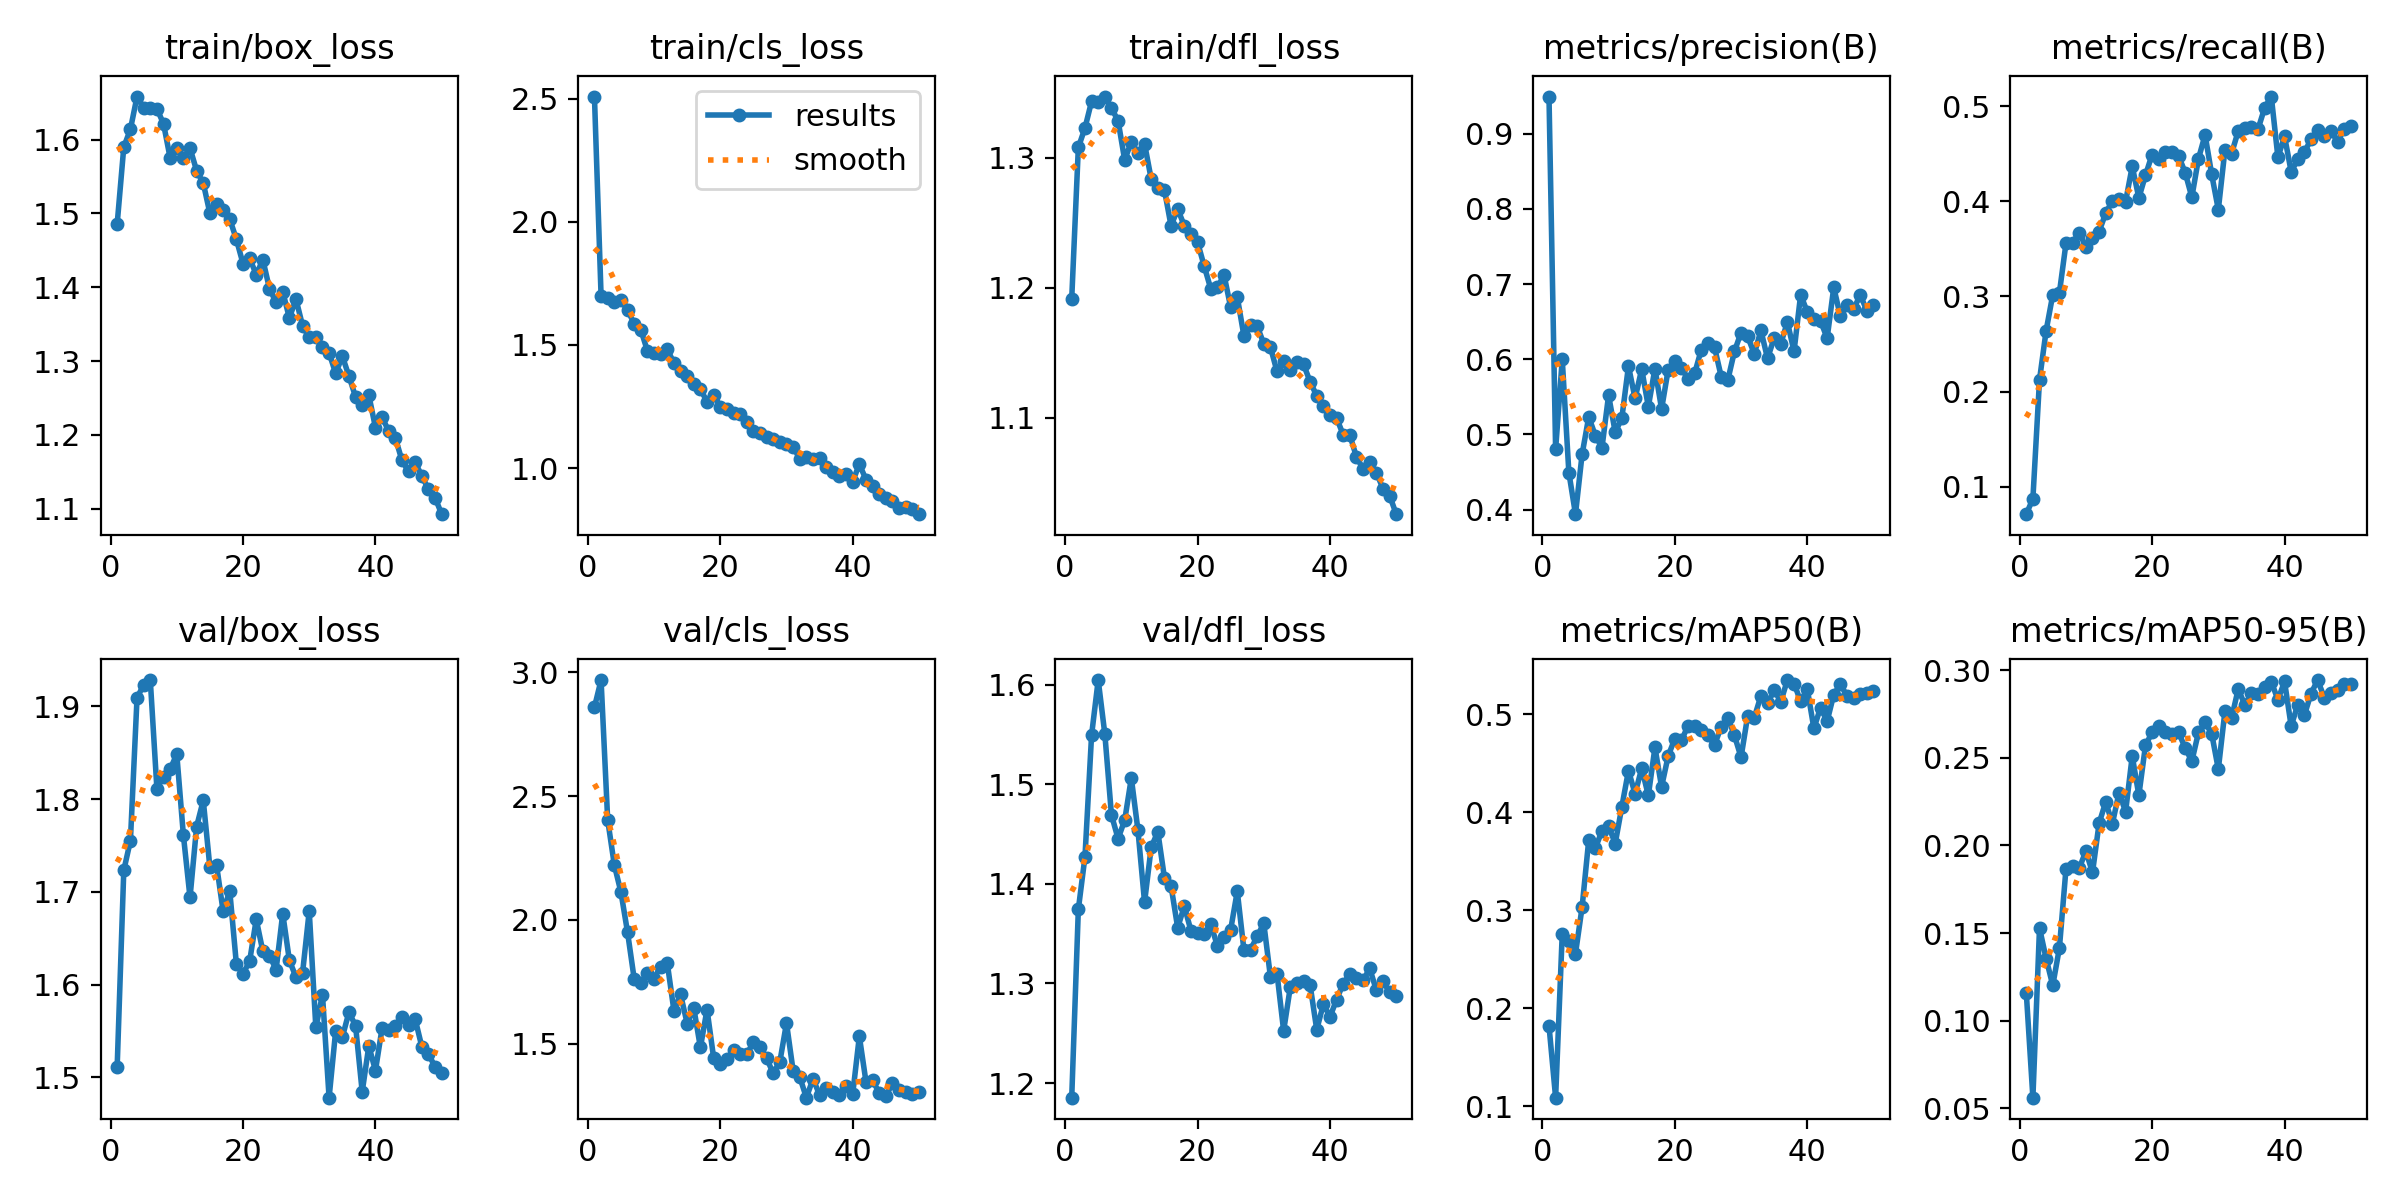

In [7]:
metrics = model.val()
print(metrics)

from IPython.display import Image
Image(filename='runs/detect/train-2/results.png')

# Predicciones usando el modelo


image 1/1 /content/Test2.jpg: 640x512 1 person, 1 car, 63.3ms
Speed: 3.7ms preprocess, 63.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 512)
Results saved to /content/runs/detect/predict


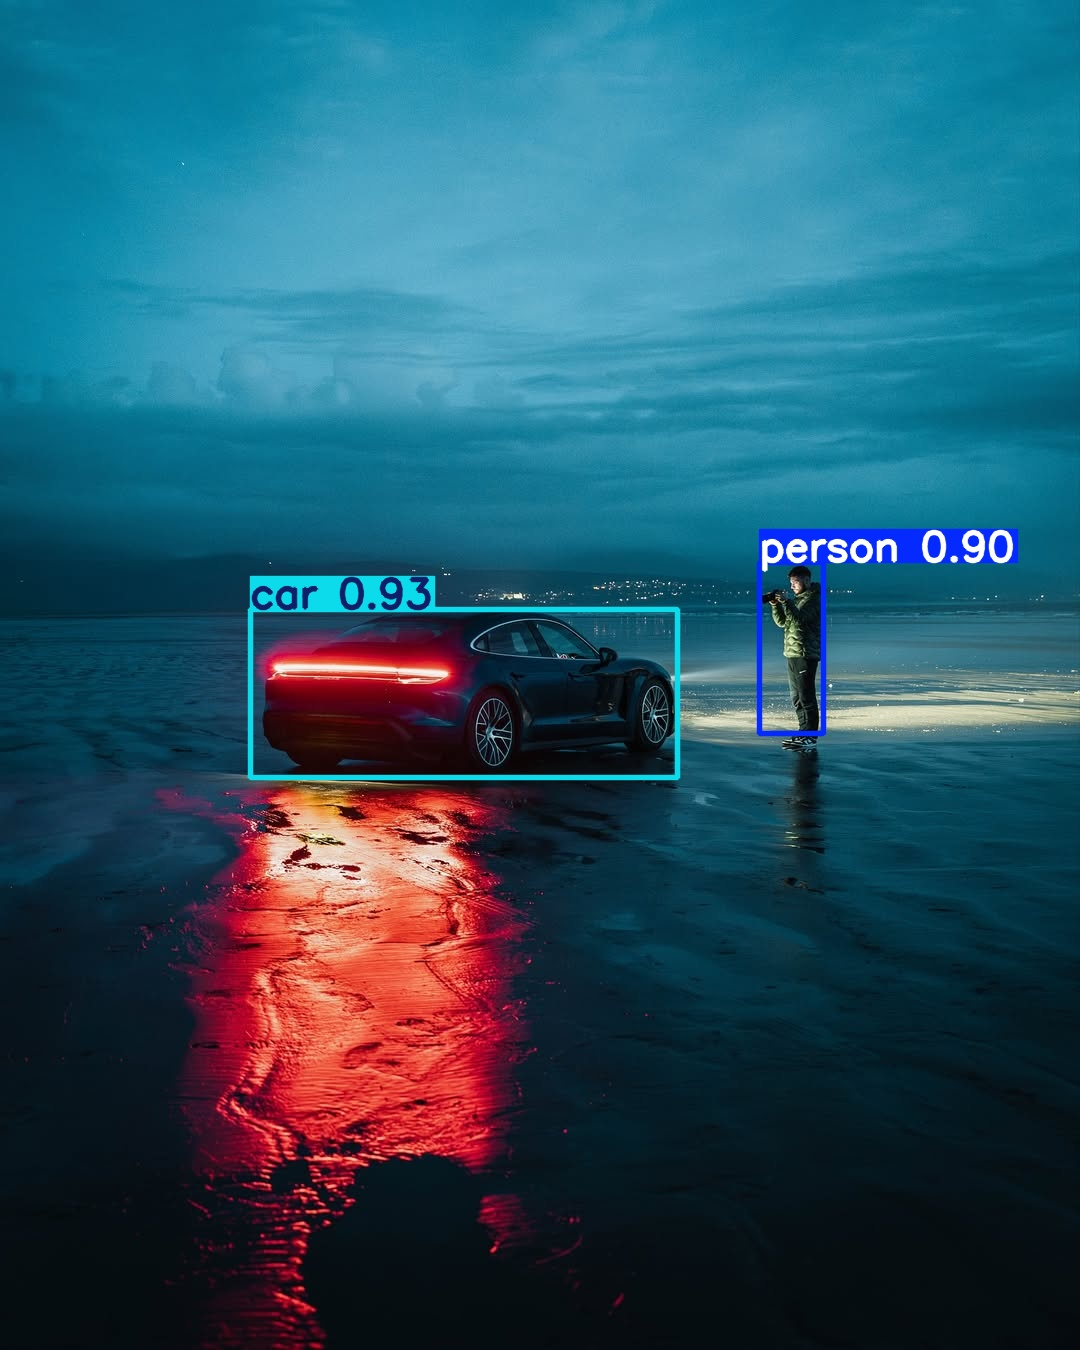

In [17]:
from PIL import Image

model = YOLO('runs/detect/train-2/weights/best.pt')
results = model('/content/Test.jpg', save=True)
display(Image.open('/content/runs/detect/predict/Test.jpg'))

# Exportar Modelo

In [18]:
model.export(format='onnx') # otros formatos: torchscript, coreml, tflite

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/train-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 460ms
Prepared 4 packages in 4.29s
Installed 4 packages in 510ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 6.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 8.7s, saved as 'runs/detect/train-2/w

'runs/detect/train-2/weights/best.onnx'